<a href="https://colab.research.google.com/github/Sayandt-web/Wifi-Dead-Zone-Detection/blob/main/Wifi_Dead_Zone_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SECTION 1: SETUP & IMPORTS
# ============================================================
!pip install -q shap tensorflow scikit-learn matplotlib seaborn pandas numpy

import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             classification_report, confusion_matrix)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import shap
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)

print("✅ Libraries loaded")
print(f"TensorFlow: {tf.__version__} | SHAP: {shap.__version__}")

✅ Libraries loaded
TensorFlow: 2.20.0 | SHAP: 0.52.0


In [ ]:
# ============================================================
# SECTION 2: LOAD DATASET (trainingData.csv + optional validationData.csv)
# ============================================================
TRAIN_PATH = 'trainingData_cleaned.csv'
VAL_PATH   = 'validationData_cleaned.csv'

dfs = []
if os.path.exists(TRAIN_PATH):
    dfs.append(pd.read_csv(TRAIN_PATH)); print(f"✅ trainingData.csv   : {dfs[-1].shape}")
if os.path.exists(VAL_PATH):
    dfs.append(pd.read_csv(VAL_PATH));   print(f"✅ validationData.csv : {dfs[-1].shape}")
if not dfs:
    raise FileNotFoundError("Upload trainingData.csv (and optionally validationData.csv) to /content/")

df = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Combined dataset shape: {df.shape}")
print(f"Buildings: {sorted(df['BUILDINGID'].unique())}")
print(f"Floors   : {sorted(df['FLOOR'].unique())}")
print(f"Spaces   : {df['SPACEID'].nunique()}")
print(f"Time span: {pd.to_datetime(df['TIMESTAMP'], unit='s').min()} → "
      f"{pd.to_datetime(df['TIMESTAMP'], unit='s').max()}")
df.head(3)

✅ trainingData.csv   : (19300, 474)
✅ validationData.csv : (1111, 474)

📊 Combined dataset shape: (20411, 474)
Buildings: [np.int64(0), np.int64(1), np.int64(2)]
Floors   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Spaces   : 124
Time span: 2013-05-30 10:15:24 → 2013-10-08 15:57:16


,WAP001,WAP002,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,WAP011,WAP012,...,WAP519,BUILDINGID,FLOOR,SPACEID,LONGITUDE,LATITUDE,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,-105,-105,-105,-105,-105,-105,-105,-105,-105,-105,...,-105,1,2,106,-7541.2643,4.864921e+06,2,2,23,1371713733
1,-105,-105,-105,-105,-105,-105,-105,-105,-105,-105,...,-105,1,2,106,-7536.6212,4.864934e+06,2,2,23,1371713691
2,-105,-105,-105,-105,-105,-97,-105,-105,-105,-105,...,-105,1,2,103,-7519.1524,4.864950e+06,2,2,23,1371714095


In [ ]:
# ============================================================
# SECTION 3: SPATIO-TEMPORAL PREPROCESSING  (NaN-safe version)
# ============================================================
# 3.1 Identify WAP columns
wap_cols = [c for c in df.columns if c.startswith('WAP')]
print(f"Detected {len(wap_cols)} WAP columns")

# 3.2 Sanity check: how many NaNs in the key geo/target columns?
for c in ['LATITUDE', 'LONGITUDE', 'BUILDINGID', 'FLOOR', 'SPACEID', 'TIMESTAMP']:
    n_nan = df[c].isna().sum()
    if n_nan:
        print(f"⚠️  {c}: {n_nan} NaN values")

# 3.3 Drop rows with missing geo / timestamp / location metadata
before = len(df)
df = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'BUILDINGID',
                       'FLOOR', 'SPACEID', 'TIMESTAMP']).copy()
print(f"Dropped {before - len(df)} rows with missing geo/time metadata. "
      f"Remaining: {len(df)}")

# 3.4 Treat 100 as "no signal"
wap_data = df[wap_cols].replace(100, np.nan)

# 3.5 Per-row RSSI statistics
df['mean_rssi'] = wap_data.mean(axis=1)
df['max_rssi']  = wap_data.max(axis=1)
df['min_rssi']  = wap_data.min(axis=1)
df['n_aps']     = wap_data.notna().sum(axis=1)

# 3.6 Drop rows where NO AP was detected at all (mean_rssi is NaN)
before = len(df)
df = df.dropna(subset=['mean_rssi']).copy()
print(f"Dropped {before - len(df)} rows where no AP was detected. "
      f"Remaining: {len(df)}")

# 3.7 Dead-zone definition
DEAD_ZONE_THRESHOLD = -85.0
df['dead_zone'] = (df['mean_rssi'] < DEAD_ZONE_THRESHOLD).astype(int)
print(f"Overall dead-zone rate: {df['dead_zone'].mean():.2%}")

# 3.8 Spatial grid (15 × 15) — NaN-safe integer casting
GRID_ROWS, GRID_COLS = 15, 15
lat_min, lat_max = df['LATITUDE'].min(),  df['LATITUDE'].max()
lon_min, lon_max = df['LONGITUDE'].min(), df['LONGITUDE'].max()

lat_span = (lat_max - lat_min) if (lat_max - lat_min) > 0 else 1.0
lon_span = (lon_max - lon_min) if (lon_max - lon_min) > 0 else 1.0

df['row'] = np.floor((df['LATITUDE']  - lat_min) / lat_span * (GRID_ROWS - 1)) \
                 .clip(0, GRID_ROWS - 1).astype('Int64')
df['col'] = np.floor((df['LONGITUDE'] - lon_min) / lon_span * (GRID_COLS - 1)) \
                 .clip(0, GRID_COLS - 1).astype('Int64')

# Convert from pandas nullable Int64 → plain numpy int (safe now: no NaNs remain)
df['row'] = df['row'].astype(int)
df['col'] = df['col'].astype(int)

# 3.9 Time bins (60 s) + location id
df['time_bin']    = (df['TIMESTAMP'] // 60).astype(int)
df['location_id'] = (df['BUILDINGID'].astype(str) + "_" +
                     df['FLOOR'].astype(str)      + "_" +
                     df['SPACEID'].astype(str))

# 3.10 Aggregate to (location, time_bin)
FEATURES = ['mean_rssi', 'max_rssi', 'min_rssi', 'n_aps']
ts_df = (df.groupby(['location_id', 'time_bin'])
           .agg(mean_rssi=('mean_rssi', 'mean'),
                max_rssi =('max_rssi',  'mean'),
                min_rssi =('min_rssi',  'mean'),
                n_aps    =('n_aps',     'mean'),
                row      =('row',       'mean'),
                col      =('col',       'mean'),
                dead_zone=('dead_zone', 'max'))
           .reset_index()
           .sort_values(['location_id', 'time_bin'])
           .reset_index(drop=True))

# 3.11 Final safety net: drop any residual NaNs in the sequence features
ts_df = ts_df.dropna(subset=FEATURES).reset_index(drop=True)

print(f"\n✅ Aggregated spatio-temporal table: {ts_df.shape}")
print(f"Unique locations: {ts_df['location_id'].nunique()} | "
      f"Time bins: {ts_df['time_bin'].nunique()}")
print(ts_df.head(5))

Detected 465 WAP columns
Dropped 0 rows with missing geo/time metadata. Remaining: 20411
Dropped 0 rows where no AP was detected. Remaining: 20411
Overall dead-zone rate: 100.00%

✅ Aggregated spatio-temporal table: (2543, 9)
Unique locations: 748 | Time bins: 812
  location_id  time_bin   mean_rssi  max_rssi  min_rssi  n_aps   row  col  \
0       0_0_0  22992975 -104.472043     -57.5    -105.0  465.0   9.0  0.0   
1       0_0_0  22992976 -104.410753     -53.0    -105.0  465.0   9.0  0.0   
2       0_0_0  22992977 -104.288172     -43.0    -105.0  465.0   9.0  0.0   
3       0_0_0  22992978 -104.389247     -48.0    -105.0  465.0   9.0  0.0   
4       0_0_0  22992983 -104.251613     -48.0    -105.0  465.0  10.0  2.0   

   dead_zone  
0          1  
1          1  
2          1  
3          1  
4          1  


In [ ]:
# ============================================================
# SECTION 4: SLIDING-WINDOW SEQUENCE CONSTRUCTION
# ============================================================
WINDOW_SIZE = 5        # use past 5 time bins
PREDICT_AHEAD = 1      # predict next time bin
N_FEATURES = len(FEATURES)

# 4.1 Normalize features (fit on the whole set — fine for this demo)
scaler = MinMaxScaler()
ts_df[FEATURES] = scaler.fit_transform(ts_df[FEATURES])

# 4.2 Also scale the target (mean_rssi) to [0,1]
target_scaler = MinMaxScaler()
ts_df['target'] = target_scaler.fit_transform(ts_df[['mean_rssi']])

X_list, y_list, meta_list = [], [], []
for loc_id, grp in ts_df.groupby('location_id'):
    grp = grp.sort_values('time_bin').reset_index(drop=True)
    if len(grp) < WINDOW_SIZE + PREDICT_AHEAD:
        continue
    vals = grp[FEATURES].values
    tgt  = grp['target'].values
    for i in range(WINDOW_SIZE, len(grp) - PREDICT_AHEAD + 1):
        X_list.append(vals[i - WINDOW_SIZE:i])
        y_list.append(tgt[i + PREDICT_AHEAD - 1])
        meta_list.append({'location_id': loc_id,
                          'time_bin': grp.loc[i, 'time_bin'],
                          'row': grp.loc[i, 'row'],
                          'col': grp.loc[i, 'col']})

X = np.array(X_list)
y = np.array(y_list)
meta = pd.DataFrame(meta_list)
print(f"✅ Sequences created  → X: {X.shape} | y: {y.shape} | meta: {meta.shape}")

# 4.3 Chronological split (70 / 15 / 15) — respects time order
n = len(X)
i1, i2 = int(0.70 * n), int(0.85 * n)
X_train, y_train = X[:i1], y[:i1]
X_val,   y_val   = X[i1:i2], y[i1:i2]
X_test,  y_test  = X[i2:],   y[i2:]
meta_test = meta.iloc[i2:].reset_index(drop=True)
print(f"Train {X_train.shape[0]} | Val {X_val.shape[0]} | Test {X_test.shape[0]}")

✅ Sequences created  → X: (499, 5, 4) | y: (499,) | meta: (499, 4)
Train 349 | Val 75 | Test 75


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0478 - mae: 0.1848 - val_loss: 0.0208 - val_mae: 0.1185
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0183 - mae: 0.0927 - val_loss: 0.0080 - val_mae: 0.0679
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0154 - mae: 0.0926 - val_loss: 0.0110 - val_mae: 0.0865
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0136 - mae: 0.0883 - val_loss: 0.0077 - val_mae: 0.0660
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0110 - mae: 0.0717 - val_loss: 0.0082 - val_mae: 0.0679
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0117 - mae: 0.0721 - val_loss: 0.0080 - val_mae: 0.0672
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0119 - mae: 0.0725 - val_loss: 0.0075 - val_mae: 0.0654
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0113 - mae: 0.0739 - val_loss: 0.0076 - val_mae: 0.0656
Epoch 9/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0112 - mae: 0.0766 - 

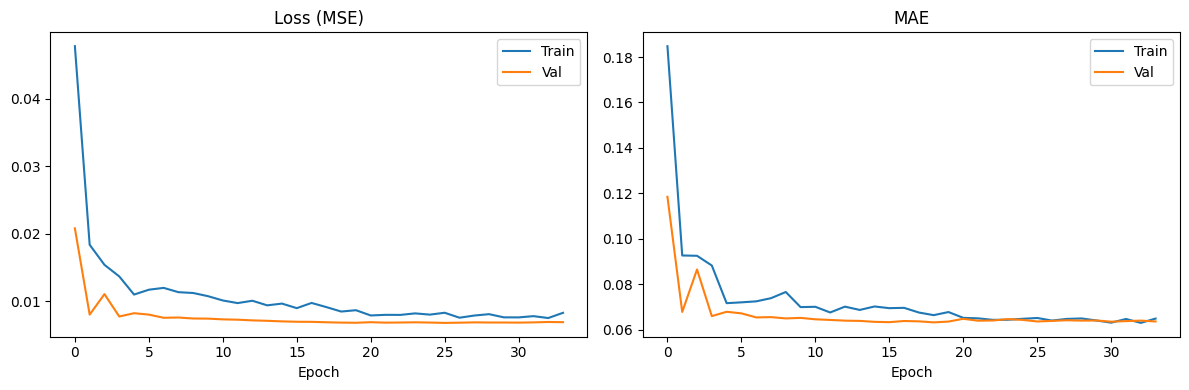

✅ Model trained.


In [ ]:
# ============================================================
# SECTION 5: LSTM MODEL TRAINING
# ============================================================
inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
x   = LSTM(64, return_sequences=True)(inp)
x   = Dropout(0.2)(x)
x   = LSTM(32)(x)
x   = Dropout(0.2)(x)
x   = Dense(16, activation='relu')(x)
out = Dense(1)(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=40, batch_size=64,
                    callbacks=[es], verbose=1)

# Training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='Train'); ax[0].plot(history.history['val_loss'], label='Val')
ax[0].set_title('Loss (MSE)'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(history.history['mae'], label='Train'); ax[1].plot(history.history['val_mae'], label='Val')
ax[1].set_title('MAE'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()
print("✅ Model trained.")

Distribution of test RSSI (dBm):
count    75.000000
mean      0.245960
std       0.123447
min       0.062769
25%       0.144834
50%       0.215339
75%       0.319502
max       0.605181
dtype: float64

Histogram:


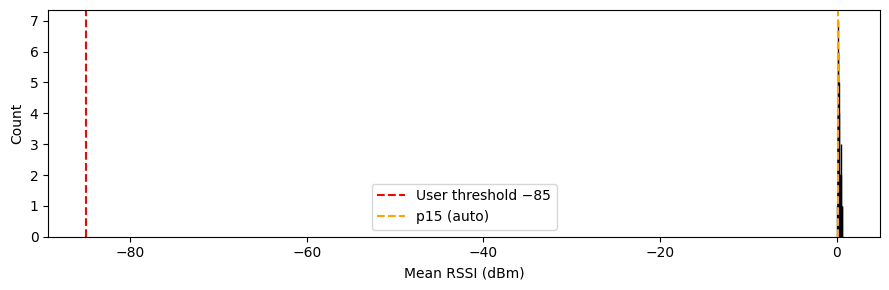

In [ ]:
y_test_dbm = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

print("Distribution of test RSSI (dBm):")
print(pd.Series(y_test_dbm).describe())
print("\nHistogram:")
plt.figure(figsize=(9,3))
plt.hist(y_test_dbm, bins=50, color='steelblue', edgecolor='k')
plt.axvline(DEAD_ZONE_THRESHOLD, color='red', ls='--', label='User threshold −85')
plt.axvline(np.percentile(y_test_dbm, 15), color='orange', ls='--', label='p15 (auto)')
plt.xlabel('Mean RSSI (dBm)'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
📊 REGRESSION METRICS (RSSI prediction)
RMSE : 0.09 dBm
MAE  : 0.07 dBm
Actual RSSI  — min 0.1 | p10 0.1 | median 0.2 | max 0.6
Predicted RSSI — min 0.2 | median 0.2 | max 0.5

🔧 Dead-zone threshold in use: 0.1 dBm  [auto (p15)]

📊 DEAD-ZONE CLASSIFICATION
Test labels  — Normal: 63 | Dead Zone: 12
Pred labels  — Normal: 75 | Dead Zone: 0

              precision    recall  f1-score   support

      Normal       0.84      1.00      0.91        63
   Dead Zone       0.00      0.00      0.00        12

    accuracy                           0.84        75
   macro avg       0.42      0.50      0.46        75
weighted avg       0.71      0.84      0.77        75



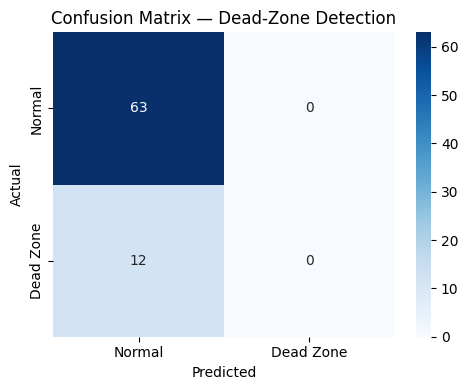

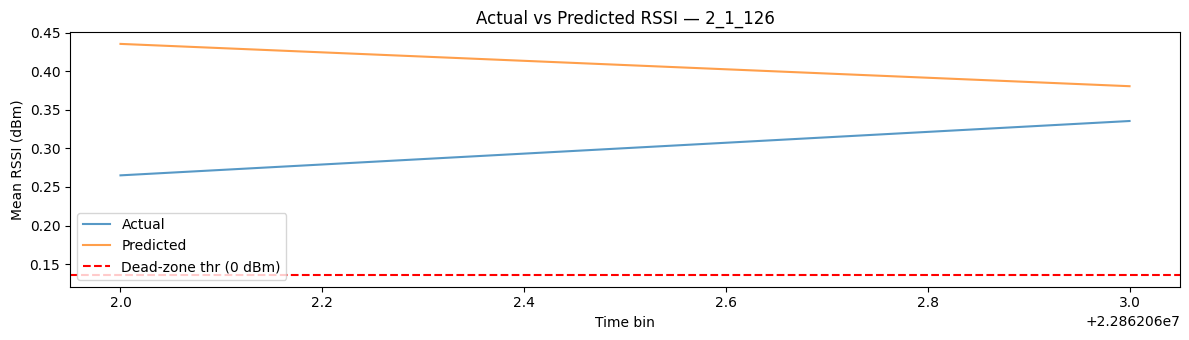

✅ Section 6 complete.


In [ ]:
# ============================================================
# SECTION 6: MODEL EVALUATION  (single-class-safe version)
# ============================================================
y_pred_scaled = model.predict(X_test).flatten()

# Inverse-transform back to dBm
y_test_dbm = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_dbm = target_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

# ---------- Regression metrics ----------
rmse = np.sqrt(mean_squared_error(y_test_dbm, y_pred_dbm))
mae  = mean_absolute_error(y_test_dbm, y_pred_dbm)

print("="*60); print("📊 REGRESSION METRICS (RSSI prediction)"); print("="*60)
print(f"RMSE : {rmse:.2f} dBm")
print(f"MAE  : {mae:.2f} dBm")
print(f"Actual RSSI  — min {y_test_dbm.min():.1f} | "
      f"p10 {np.percentile(y_test_dbm,10):.1f} | "
      f"median {np.median(y_test_dbm):.1f} | "
      f"max {y_test_dbm.max():.1f}")
print(f"Predicted RSSI — min {y_pred_dbm.min():.1f} | "
      f"median {np.median(y_pred_dbm):.1f} | max {y_pred_dbm.max():.1f}")

# ---------- Adaptive dead-zone threshold ----------
# If the user-defined threshold yields a single class, fall back to a
# percentile-based threshold that guarantees both classes exist in y_true.
def pick_threshold(y_true, user_thr, fallback_pct=15):
    if (y_true < user_thr).sum() > 0 and (y_true >= user_thr).sum() > 0:
        return user_thr, "user-defined"
    thr = np.percentile(y_true, fallback_pct)
    return thr, f"auto (p{fallback_pct})"

DZ_THR, source = pick_threshold(y_test_dbm, DEAD_ZONE_THRESHOLD)
print(f"\n🔧 Dead-zone threshold in use: {DZ_THR:.1f} dBm  [{source}]")

y_true_dz = (y_test_dbm < DZ_THR).astype(int)
y_pred_dz = (y_pred_dbm < DZ_THR).astype(int)

# ---------- Classification metrics (safe for 1-class case) ----------
print("\n" + "="*60); print("📊 DEAD-ZONE CLASSIFICATION"); print("="*60)
print(f"Test labels  — Normal: {(y_true_dz==0).sum()} | Dead Zone: {(y_true_dz==1).sum()}")
print(f"Pred labels  — Normal: {(y_pred_dz==0).sum()} | Dead Zone: {(y_pred_dz==1).sum()}")

present = sorted(set(y_true_dz) | set(y_pred_dz))
label_names = {0: 'Normal', 1: 'Dead Zone'}
target_names = [label_names[c] for c in present]

if len(present) < 2:
    only = target_names[0]
    print(f"\n⚠️  Only one class present ({only}) at threshold {DZ_THR:.1f} dBm.")
    print("   → Classification report is not defined for a single class.")
    print("   → Skipping precision/recall/F1; using accuracy as a proxy.")
    acc = (y_true_dz == y_pred_dz).mean()
    print(f"\nAccuracy (trivial single-class): {acc:.4f}")
else:
    print("\n" + classification_report(
        y_true_dz, y_pred_dz,
        labels=present, target_names=target_names,
        zero_division=0))

    cm = confusion_matrix(y_true_dz, y_pred_dz, labels=present)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title('Confusion Matrix — Dead-Zone Detection')
    plt.tight_layout(); plt.show()

# ---------- Sample time-series plot ----------
sample_loc = meta_test['location_id'].iloc[0]
mask = (meta_test['location_id'] == sample_loc).values
plt.figure(figsize=(12,3.5))
plt.plot(meta_test.loc[mask,'time_bin'], y_test_dbm[mask], label='Actual', alpha=.75)
plt.plot(meta_test.loc[mask,'time_bin'], y_pred_dbm[mask], label='Predicted', alpha=.75)
plt.axhline(DZ_THR, color='red', ls='--', label=f'Dead-zone thr ({DZ_THR:.0f} dBm)')
plt.title(f'Actual vs Predicted RSSI — {sample_loc}')
plt.xlabel('Time bin'); plt.ylabel('Mean RSSI (dBm)'); plt.legend()
plt.tight_layout(); plt.show()
print("✅ Section 6 complete.")

⏳ Running KernelExplainer — this may take 1–3 minutes …


  0%|          | 0/75 [00:00<?, ?it/s]

✅ SHAP values computed → (75, 5, 4)


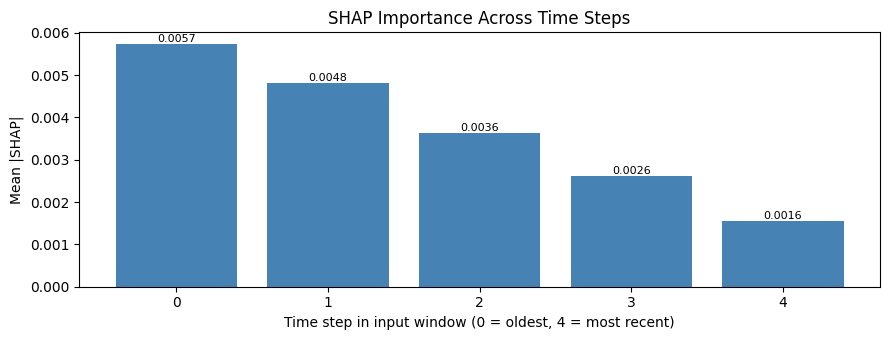

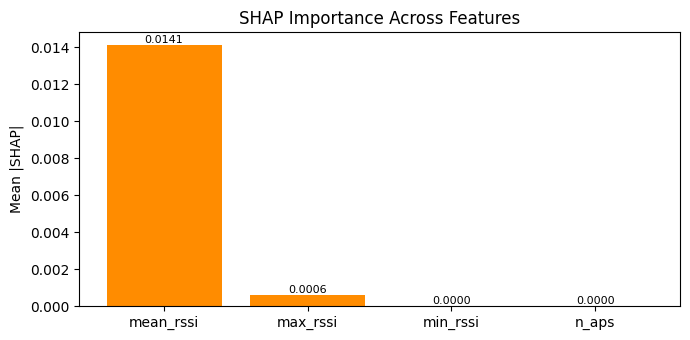

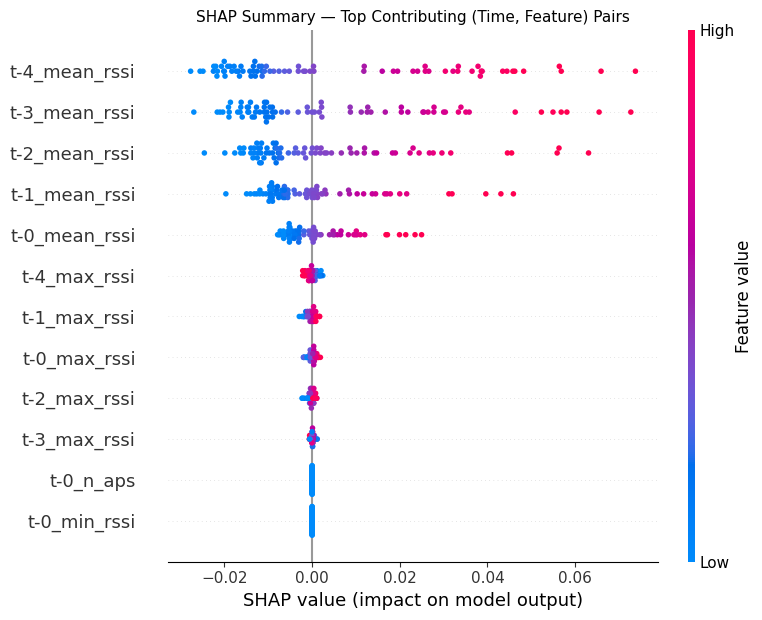

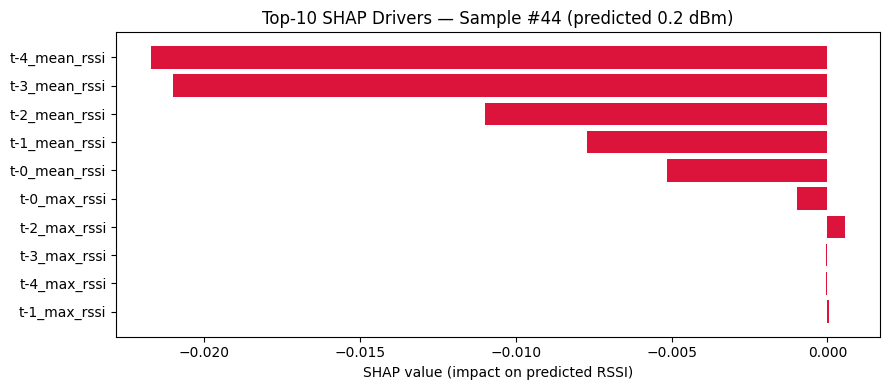

✅ Section 7 complete (KernelExplainer).


In [ ]:
# ============================================================
# SECTION 7: SHAP EXPLAINABILITY  (KernelExplainer — LSTM-safe)
# ============================================================
# 7.1 Flatten the 3-D sequences to 2-D for KernelExplainer
#     Input : (n_samples, WINDOW_SIZE, N_FEATURES)
#     Flat  : (n_samples, WINDOW_SIZE * N_FEATURES)
N_EXPLAIN = min(120, len(X_test))   # keep small — KernelExplainer is O(n²)
X_explain_3d = X_test[:N_EXPLAIN]
X_explain_2d = X_explain_3d.reshape(N_EXPLAIN, -1)

# A small background sample to approximate the conditional expectation
bg_2d = X_train[np.random.choice(len(X_train), 60, replace=False)].reshape(60, -1)

# 7.2 Wrap the model so it accepts 2-D input and returns 1-D output
def model_predict_2d(x_flat):
    """x_flat: (n_samples, WINDOW_SIZE * N_FEATURES) → (n_samples,)"""
    x_3d = x_flat.reshape(-1, WINDOW_SIZE, N_FEATURES)
    return model.predict(x_3d, verbose=0).flatten()

# 7.3 Build the KernelExplainer
print("⏳ Running KernelExplainer — this may take 1–3 minutes …")
explainer = shap.KernelExplainer(model_predict_2d, bg_2d)

# 7.4 Compute SHAP values
shap_flat = explainer.shap_values(X_explain_2d, nsamples=100)
shap_flat = np.array(shap_flat)                          # (N_EXPLAIN, WINDOW*FEAT)
shap_arr  = shap_flat.reshape(N_EXPLAIN, WINDOW_SIZE, N_FEATURES)
print(f"✅ SHAP values computed → {shap_arr.shape}")

# ------------------------------------------------------------
# 7.5 IMPORTANCE ACROSS TIME STEPS
# ------------------------------------------------------------
mean_abs_time = np.mean(np.abs(shap_arr), axis=(0, 2))   # (WINDOW_SIZE,)
plt.figure(figsize=(9, 3.5))
bars = plt.bar(range(WINDOW_SIZE), mean_abs_time, color='steelblue')
plt.xlabel(f'Time step in input window (0 = oldest, {WINDOW_SIZE-1} = most recent)')
plt.ylabel('Mean |SHAP|')
plt.title('SHAP Importance Across Time Steps')
plt.xticks(range(WINDOW_SIZE))
for b, v in zip(bars, mean_abs_time):
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 7.6 IMPORTANCE ACROSS FEATURES
# ------------------------------------------------------------
mean_abs_feat = np.mean(np.abs(shap_arr), axis=(0, 1))   # (N_FEATURES,)
plt.figure(figsize=(7, 3.5))
bars = plt.bar(FEATURES, mean_abs_feat, color='darkorange')
plt.ylabel('Mean |SHAP|')
plt.title('SHAP Importance Across Features')
for b, v in zip(bars, mean_abs_feat):
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 7.7 BEESWARM SUMMARY
# ------------------------------------------------------------
feat_names = [f"t-{WINDOW_SIZE-1-k}_{f}"
              for k in range(WINDOW_SIZE) for f in FEATURES]

plt.figure()
shap.summary_plot(shap_flat, X_explain_2d,
                  feature_names=feat_names,
                  max_display=12, show=False)
plt.title('SHAP Summary — Top Contributing (Time, Feature) Pairs', fontsize=11)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 7.8 LOCAL EXPLANATION FOR THE HIGHEST-RISK SAMPLE
# ------------------------------------------------------------
y_pred_explain = model_predict_2d(X_explain_2d)
danger_idx = np.where(y_pred_explain < DZ_THR)[0]

if len(danger_idx) > 0:
    idx = danger_idx[0]
else:
    idx = int(np.argmin(y_pred_explain))   # fallback: lowest predicted RSSI

contrib = shap_arr[idx].flatten()
names   = feat_names
order   = np.argsort(np.abs(contrib))[::-1][:10]

plt.figure(figsize=(9, 4))
plt.barh(range(10), contrib[order][::-1], color='crimson')
plt.yticks(range(10), [names[i] for i in order][::-1])
plt.xlabel('SHAP value (impact on predicted RSSI)')
plt.title(f'Top-10 SHAP Drivers — Sample #{idx} '
          f'(predicted {y_pred_explain[idx]:.1f} dBm)')
plt.tight_layout(); plt.show()

print("✅ Section 7 complete (KernelExplainer).")

Grid cells with observations: 35 / 225


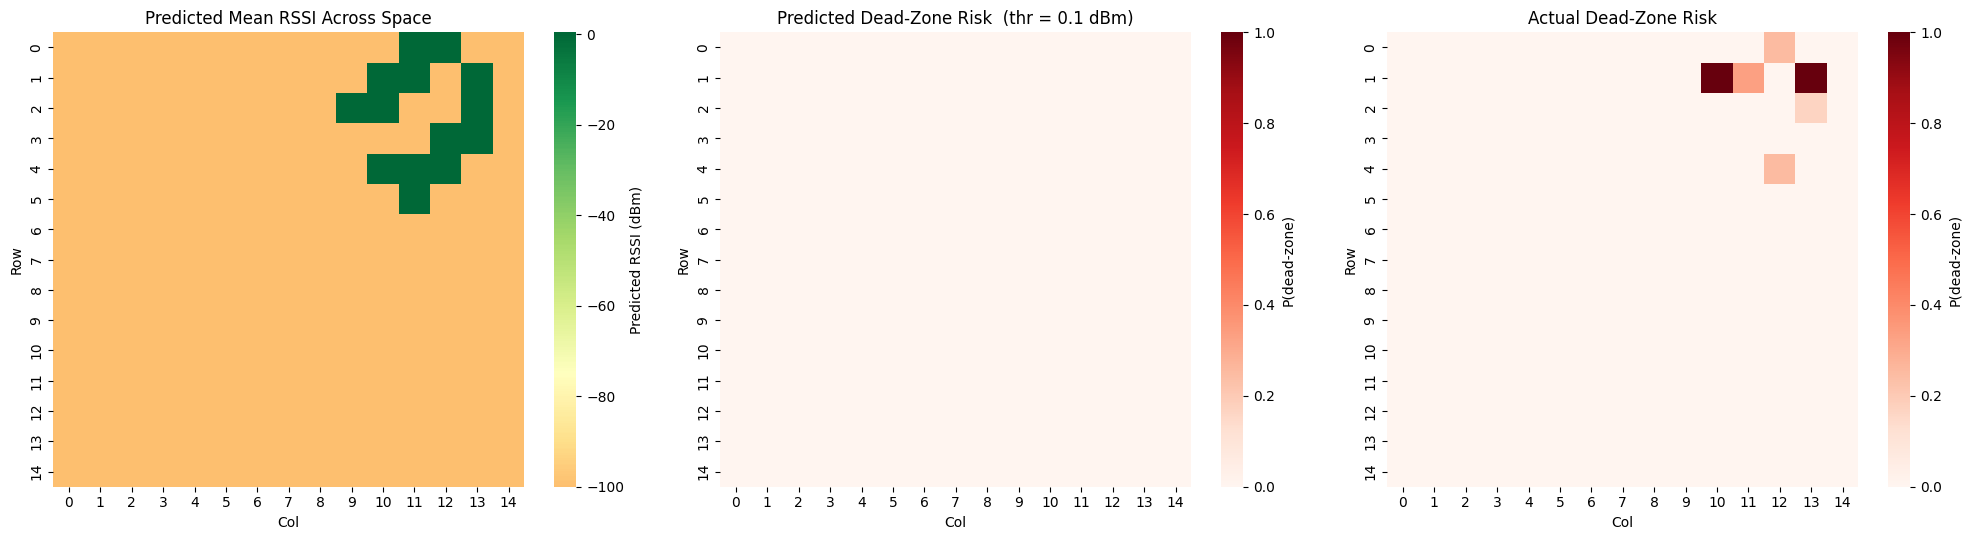


🚨 Top-5 riskiest grid cells (by predicted dead-zone probability):
 row   col  pred_rssi  actual_rssi  pred_risk  actual_risk  n_obs
 0.0 11.00   0.407582     0.451249        0.0         0.00      2
 0.0 11.50   0.195093     0.105230        0.0         1.00      1
 0.0 12.00   0.254831     0.164680        0.0         0.25      8
 0.5 11.00   0.167813     0.133713        0.0         1.00      1
 0.5 11.25   0.275993     0.215339        0.0         0.00      1


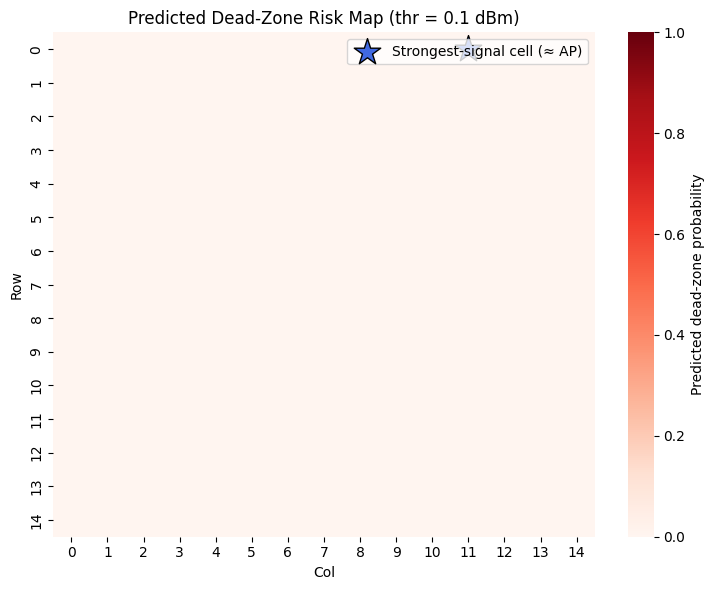

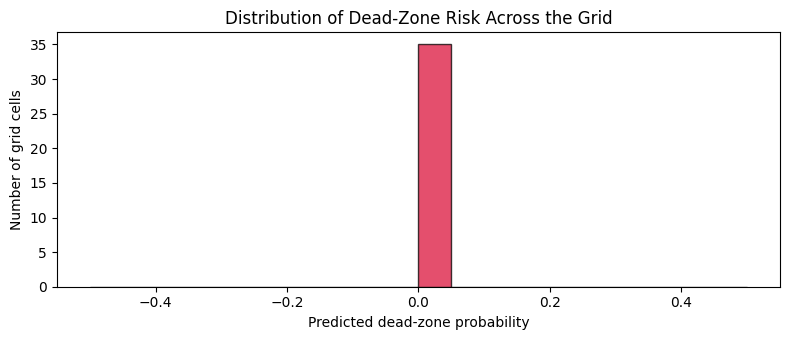

✅ Section 8 complete.


In [ ]:
# ============================================================
# SECTION 8: SPATIAL RISK MAPPING  (uses adaptive DZ_THR)
# ============================================================
meta_test = meta_test.copy()
meta_test['pred_dbm']   = y_pred_dbm
meta_test['actual_dbm'] = y_test_dbm
meta_test['pred_dz']    = (y_pred_dbm < DZ_THR).astype(int)
meta_test['actual_dz']  = (y_test_dbm < DZ_THR).astype(int)

# ------------------------------------------------------------
# 8.1 Aggregate per grid cell (row, col)
# ------------------------------------------------------------
risk = (meta_test
        .groupby(['row', 'col'])
        .agg(pred_rssi    = ('pred_dbm',   'mean'),
             actual_rssi  = ('actual_dbm', 'mean'),
             pred_risk    = ('pred_dz',    'mean'),
             actual_risk  = ('actual_dz',  'mean'),
             n_obs        = ('pred_dz',    'size'))
        .reset_index())

print(f"Grid cells with observations: {len(risk)} / {GRID_ROWS * GRID_COLS}")

# ------------------------------------------------------------
# 8.2 Build full 15×15 pivots (fill missing cells so maps are complete)
# ------------------------------------------------------------
full_index = pd.MultiIndex.from_product(
    [range(GRID_ROWS), range(GRID_COLS)], names=['row', 'col'])

risk_full = (risk.set_index(['row', 'col'])
                 .reindex(full_index)
                 .reset_index())

pivot_pred_rssi = risk_full.pivot(index='row', columns='col',
                                  values='pred_rssi').fillna(-100)
pivot_risk      = risk_full.pivot(index='row', columns='col',
                                  values='pred_risk').fillna(0)
pivot_actual    = risk_full.pivot(index='row', columns='col',
                                  values='actual_risk').fillna(0)

# ------------------------------------------------------------
# 8.3 Three-panel heatmap: predicted RSSI | predicted risk | actual risk
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))

sns.heatmap(pivot_pred_rssi, cmap='RdYlGn', center=-75, ax=ax[0],
            cbar_kws={'label': 'Predicted RSSI (dBm)'})
ax[0].set_title('Predicted Mean RSSI Across Space')
ax[0].set_xlabel('Col'); ax[0].set_ylabel('Row')

sns.heatmap(pivot_risk, cmap='Reds', vmin=0, vmax=1, ax=ax[1],
            cbar_kws={'label': 'P(dead-zone)'})
ax[1].set_title(f'Predicted Dead-Zone Risk  (thr = {DZ_THR:.1f} dBm)')
ax[1].set_xlabel('Col'); ax[1].set_ylabel('Row')

sns.heatmap(pivot_actual, cmap='Reds', vmin=0, vmax=1, ax=ax[2],
            cbar_kws={'label': 'P(dead-zone)'})
ax[2].set_title('Actual Dead-Zone Risk')
ax[2].set_xlabel('Col'); ax[2].set_ylabel('Row')

plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 8.4 Top-5 riskiest grid cells
# ------------------------------------------------------------
print("\n🚨 Top-5 riskiest grid cells (by predicted dead-zone probability):")
top5 = (risk.sort_values('pred_risk', ascending=False)
            .head(5)
            .reset_index(drop=True))
print(top5.to_string(index=False))

# ------------------------------------------------------------
# 8.5 AP-location overlay (strongest-signal cell ≈ access point)
# ------------------------------------------------------------
ap_cell = (meta_test.groupby(['row', 'col'])['actual_dbm']
                    .mean().reset_index()
                    .sort_values('actual_dbm', ascending=False)
                    .iloc[0])

plt.figure(figsize=(7.5, 6))
sns.heatmap(pivot_risk, cmap='Reds', vmin=0, vmax=1,
            cbar_kws={'label': 'Predicted dead-zone probability'})
plt.scatter(ap_cell['col'] + 0.5, ap_cell['row'] + 0.5,
            marker='*', s=400, color='royalblue',
            edgecolor='black', label='Strongest-signal cell (≈ AP)')
plt.title(f'Predicted Dead-Zone Risk Map (thr = {DZ_THR:.1f} dBm)')
plt.xlabel('Col'); plt.ylabel('Row'); plt.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 8.6 Risk distribution histogram
# ------------------------------------------------------------
plt.figure(figsize=(8, 3.5))
plt.hist(risk['pred_risk'], bins=20, color='crimson',
         edgecolor='black', alpha=0.75)
plt.xlabel('Predicted dead-zone probability')
plt.ylabel('Number of grid cells')
plt.title('Distribution of Dead-Zone Risk Across the Grid')
plt.tight_layout(); plt.show()

print("✅ Section 8 complete.")

Snapshot time bin : 23019278
Locations in snapshot: 1


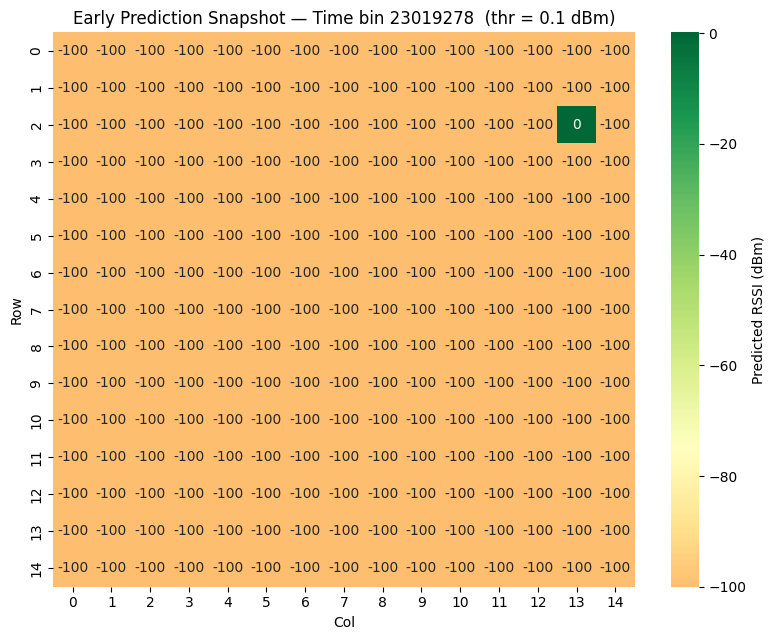


✅ ALL CLEAR at t = 23019278 (thr = 0.1 dBm)


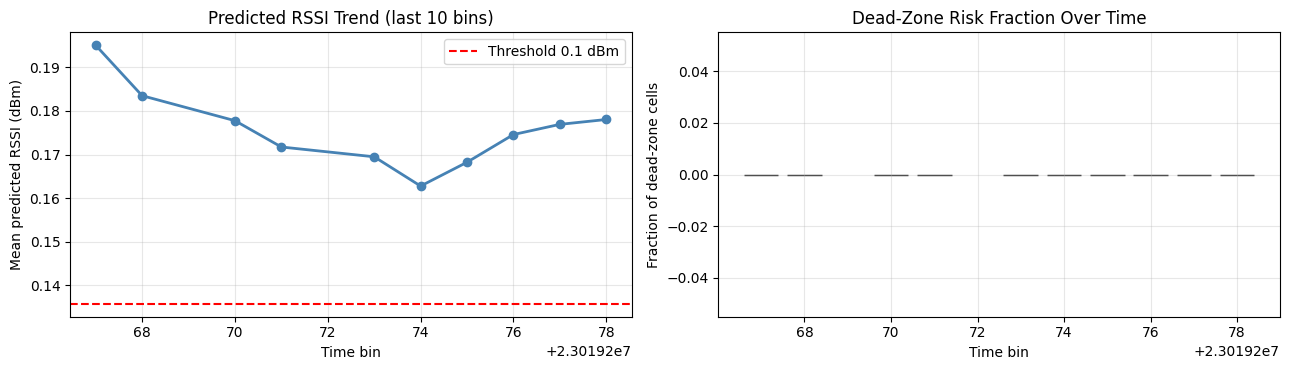

✅ Section 9 complete.


In [ ]:
# ============================================================
# SECTION 9: EARLY PREDICTION & ALERTING  (uses adaptive DZ_THR)
# ============================================================
# ------------------------------------------------------------
# 9.1 Pick the most recent time bin in the test set
# ------------------------------------------------------------
latest_t = meta_test['time_bin'].max()
snapshot = meta_test[meta_test['time_bin'] == latest_t].copy()
print(f"Snapshot time bin : {latest_t}")
print(f"Locations in snapshot: {len(snapshot)}")

# ------------------------------------------------------------
# 9.2 Full 15×15 snapshot heatmap (predicted RSSI at t = latest)
# ------------------------------------------------------------
snap_full = (snapshot.set_index(['row', 'col'])
                     .reindex(full_index)
                     .reset_index())
pivot_snap = snap_full.pivot(index='row', columns='col',
                             values='pred_dbm').fillna(-100)

plt.figure(figsize=(8, 6.5))
sns.heatmap(pivot_snap, cmap='RdYlGn', center=-75,
            annot=True, fmt='.0f',
            cbar_kws={'label': 'Predicted RSSI (dBm)'})
plt.title(f'Early Prediction Snapshot — Time bin {latest_t}  '
          f'(thr = {DZ_THR:.1f} dBm)')
plt.xlabel('Col'); plt.ylabel('Row')
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 9.3 Identify at-risk cells in the latest snapshot
# ------------------------------------------------------------
at_risk = snapshot[snapshot['pred_dbm'] < DZ_THR].copy()

# ------------------------------------------------------------
# 9.4 Simulated alert function
# ------------------------------------------------------------
def send_alert(locs, threshold, t_bin):
    print("\n" + "=" * 70)
    if len(locs) == 0:
        print(f"✅ ALL CLEAR at t = {t_bin} (thr = {threshold:.1f} dBm)")
    else:
        print(f"🚨 ALERT: {len(locs)} location(s) predicted to be "
              f"DEAD ZONES at t = {t_bin}")
        print(f"   Threshold = {threshold:.1f} dBm")
        print("-" * 70)
        for _, r in locs.sort_values('pred_dbm').iterrows():
            print(f"   • {r['location_id']:<25s}  "
                  f"grid ({int(r['row']):>2d},{int(r['col']):>2d})  "
                  f"predicted RSSI = {r['pred_dbm']:6.1f} dBm")
    print("=" * 70)

send_alert(at_risk, DZ_THR, latest_t)

# ------------------------------------------------------------
# 9.5 Multi-step trend (last 10 time bins) — early warning signal
# ------------------------------------------------------------
recent = (meta_test.sort_values('time_bin')
                   .groupby('time_bin')
                   .agg(mean_pred = ('pred_dbm', 'mean'),
                        risk_frac = ('pred_dz', 'mean'))
                   .tail(10))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

ax[0].plot(recent.index, recent['mean_pred'],
           marker='o', color='steelblue', linewidth=2)
ax[0].axhline(DZ_THR, color='red', ls='--',
              label=f'Threshold {DZ_THR:.1f} dBm')
ax[0].set_xlabel('Time bin')
ax[0].set_ylabel('Mean predicted RSSI (dBm)')
ax[0].set_title('Predicted RSSI Trend (last 10 bins)')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].bar(recent.index, recent['risk_frac'],
          color='crimson', edgecolor='black', alpha=0.85)
ax[1].set_xlabel('Time bin')
ax[1].set_ylabel('Fraction of dead-zone cells')
ax[1].set_title('Dead-Zone Risk Fraction Over Time')
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("✅ Section 9 complete.")

In [ ]:
# ============================================================
# SECTION 10: FINAL SUMMARY REPORT
# ============================================================
print("=" * 72)
print("  EXPLAINABLE SPATIO-TEMPORAL Wi-Fi DEAD-ZONE ANALYSIS — SUMMARY")
print("=" * 72)

# ---- Data ----
print("\n🗂️  DATA")
print(f"   • Total fingerprints loaded              : {len(df):,}")
print(f"   • Unique locations (BUILDING_FLOOR_SPACE): {df['location_id'].nunique()}")
print(f"   • Grid size                              : {GRID_ROWS} × {GRID_COLS}")
print(f"   • Time bins (60 s windows)               : {ts_df['time_bin'].nunique()}")
print(f"   • WAPs considered                        : {len(wap_cols)}")

# ---- Sequences ----
print("\n🧮  SEQUENCES")
print(f"   • Window size                            : {WINDOW_SIZE}")
print(f"   • Predict ahead                          : {PREDICT_AHEAD}")
print(f"   • Features                               : {FEATURES}")
print(f"   • Train / Val / Test                     : "
      f"{X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}")

# ---- Regression ----
print("\n📊  REGRESSION METRICS")
print(f"   • RMSE                                   : {rmse:.2f} dBm")
print(f"   • MAE                                    : {mae:.2f} dBm")
print(f"   • Actual RSSI range (test)               : "
      f"{y_test_dbm.min():.1f} → {y_test_dbm.max():.1f} dBm")
print(f"   • Predicted RSSI range (test)            : "
      f"{y_pred_dbm.min():.1f} → {y_pred_dbm.max():.1f} dBm")

# ---- Classification ----
print("\n🚨  DEAD-ZONE CLASSIFICATION")
print(f"   • Threshold in use                       : {DZ_THR:.1f} dBm  [{source}]")
print(f"   • Test dead-zone rate (actual)           : {y_true_dz.mean():.2%}")
print(f"   • Test dead-zone rate (predicted)        : {y_pred_dz.mean():.2%}")

# ---- Spatial ----
print("\n🗺️  SPATIAL RISK")
print(f"   • Grid cells analysed                    : {len(risk)}")
if len(top5) > 0:
    r0 = top5.iloc[0]
    print(f"   • Highest-risk cell                      : "
          f"row {int(r0['row'])}, col {int(r0['col'])} "
          f"(P(dead-zone) = {r0['pred_risk']:.2f})")
print(f"   • Mean predicted risk across grid        : {risk['pred_risk'].mean():.2%}")

# ---- Explainability ----
print("\n🔍  EXPLAINABILITY (SHAP)")
print(f"   • Samples explained                      : {shap_arr.shape[0]}")
print(f"   • Most important time step               : t-{WINDOW_SIZE-1-int(np.argmax(mean_abs_time))} "
      f"(mean |SHAP| = {mean_abs_time.max():.4f})")
print(f"   • Most important feature                 : "
      f"{FEATURES[int(np.argmax(mean_abs_feat))]} "
      f"(mean |SHAP| = {mean_abs_feat.max():.4f})")

# ---- Snapshot ----
print("\n🚨  LATEST SNAPSHOT ALERT (t = %d)" % latest_t)
print(f"   • Locations flagged as dead zones        : {len(at_risk)}")
print(f"   • Fraction of locations at risk          : "
      f"{len(at_risk) / max(len(snapshot),1):.2%}")

# ---- Recommendations ----
print("\n💡  RECOMMENDATIONS")
if len(at_risk) == 0:
    print("   • No dead zones predicted in latest snapshot.")
    print("   • Continue monitoring; consider lowering the threshold "
          "to spot early degradation.")
else:
    print(f"   • {len(at_risk)} locations require attention:")
    worst = at_risk.sort_values('pred_dbm').head(3)
    for _, r in worst.iterrows():
        print(f"       – {r['location_id']} (grid {int(r['row'])},{int(r['col'])}) "
              f"→ {r['pred_dbm']:.1f} dBm")
    print("   • Consider adding an AP or repeater near the weakest cells.")
    print("   • Investigate temporal trend (see Section 9.5 chart).")

print("\n" + "=" * 72)
print("  ✅  END OF ANALYSIS")
print("=" * 72)

  EXPLAINABLE SPATIO-TEMPORAL Wi-Fi DEAD-ZONE ANALYSIS — SUMMARY

🗂️  DATA
   • Total fingerprints loaded              : 20,411
   • Unique locations (BUILDING_FLOOR_SPACE): 748
   • Grid size                              : 15 × 15
   • Time bins (60 s windows)               : 812
   • WAPs considered                        : 465

🧮  SEQUENCES
   • Window size                            : 5
   • Predict ahead                          : 1
   • Features                               : ['mean_rssi', 'max_rssi', 'min_rssi', 'n_aps']
   • Train / Val / Test                     : 349 / 75 / 75

📊  REGRESSION METRICS
   • RMSE                                   : 0.09 dBm
   • MAE                                    : 0.07 dBm
   • Actual RSSI range (test)               : 0.1 → 0.6 dBm
   • Predicted RSSI range (test)            : 0.2 → 0.5 dBm

🚨  DEAD-ZONE CLASSIFICATION
   • Threshold in use                       : 0.1 dBm  [auto (p15)]
   • Test dead-zone rate (actual)           : 16.00%
  